# 1. Import and Hardware setup

In [1]:
!pip install wandb -q
import torch
from torchvision import datasets, transforms
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split, Subset
import torch.optim as optim
import random
import numpy as np

import matplotlib.pyplot as plt

import wandb

In [2]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_PATH = './data'
    SAVE_PATH = '/content/drive/MyDrive/DL'
    print("✅ Contected to Google Drive")
except(ValueError, ImportError, Exception) as e:
    print(f"❌ Error: {e}")
    print("❌ Failed to mount to Google Drive --> ✅ Use Local Path")
    DATA_PATH = "./data"
    SAVE_PATH = DATA_PATH

❌ Error: Mounting drive is unsupported in this environment. Use PyDrive2 instead. See examples at https://colab.research.google.com/notebooks/io.ipynb#scrollTo=7taylj9wpsA2.
❌ Failed to mount to Google Drive --> ✅ Use Local Path


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


# Log into W&B
wandb.login()

cuda


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

  ········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: blendezu (blendezu-th-k-ln) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

# 2. Hyperparameter

In [4]:
IMG_SIZE = 32
PATCH_SIZE = 4
IN_CHANNELS = 3
BATCH_SIZE = 128

# Training
LR = 3e-4
DROP_RATE = 0.4
EPOCHS = 200
SEED = 42

# ViT
EMBED_DIM = 256
MLP_DIM = 512
ENC_NUMS = 6
MSA_NUMS = 8
CLS_NUMS = 100

# 3. Traning Data Preparation

In [5]:
stats = ((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))

train_transform = transforms.Compose([
    transforms.AutoAugment(transforms.AutoAugmentPolicy.CIFAR10),
    transforms.RandomCrop(32, padding=4, padding_mode='reflect'),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ToTensor(),
    transforms.Normalize(*stats),
    transforms.RandomErasing(p=0.25)
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

In [6]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    try:
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass

set_seed(SEED)

# Dummy train set ohne transform nur für reproduzierbare Indizes
dummy_data = datasets.CIFAR100(root=DATA_PATH, train=True, download=True)
train_size = int(0.8 * len(dummy_data))
val_size = len(dummy_data) - train_size

split_generator = torch.Generator().manual_seed(SEED)
train_tmp_subset, val_tmp_subset = random_split(
    dummy_data, [train_size, val_size], generator=split_generator
)

train_indices = train_tmp_subset.indices
val_indices = val_tmp_subset.indices

# Separate datasets mit korrekten transforms
train_dataset = datasets.CIFAR100(root=DATA_PATH, train=True, download=False, transform=train_transform)
val_dataset = datasets.CIFAR100(root=DATA_PATH, train=True, download=False, transform=test_transform)

train_subset = Subset(train_dataset, train_indices)
val_subset = Subset(val_dataset, val_indices)

test_data = datasets.CIFAR100(root=DATA_PATH, train=False, download=True, transform=test_transform)

100%|██████████| 169M/169M [00:02<00:00, 80.8MB/s] 


In [7]:
def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    random.seed(worker_seed)
    np.random.seed(worker_seed)

train_gen = torch.Generator().manual_seed(SEED)
eval_gen = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(
    train_subset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=4, pin_memory=True,
    worker_init_fn=seed_worker, generator=train_gen
)

val_loader = DataLoader(
    val_subset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=4, pin_memory=True,
    worker_init_fn=seed_worker, generator=eval_gen
)

test_loader = DataLoader(
    test_data, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=4, pin_memory=True,
    worker_init_fn=seed_worker, generator=eval_gen
)

# 4. Model Architecture

In [8]:
class EmbeddedPatches(nn.Module):
    def __init__(self, img_size, in_channels, embed_dim, patch_size, batch_size):
        super().__init__()
        self.proj = nn.Conv2d(in_channels, embed_dim, patch_size, patch_size)
        N = (img_size // patch_size) ** 2
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.pos_token = nn.Parameter(torch.randn(1, N+1, embed_dim))

    def forward(self, x):
        B = x.size(0)
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        cls_token = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_token, x), dim=1)
        x = x + self.pos_token

        return x

In [9]:
class MLP(nn.Module):
    def __init__(self, in_features, out_features, drop_rate):
        super().__init__()
        self.layer1 = nn.Linear(in_features, out_features)
        self.layer2 = nn.Linear(out_features, in_features)
        self.dropout = nn.Dropout(drop_rate)

    def forward(self, x):
        x = self.layer1(x)
        x = F.gelu(x)
        x = self.dropout(x)
        x = self.layer2(x)
        x = self.dropout(x)

        return x

In [10]:
class VisionEncoder(nn.Module):
    def __init__(self, embed_dim, msa_size, mlp_dim, enc_dim, drop_rate):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, msa_size, drop_rate, batch_first=True)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = MLP(embed_dim, mlp_dim, drop_rate)

    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))

        return x


In [11]:
class ClassHead(nn.Module):
    """Classification MLP Head as described in the ViT paper.

    Architecture: LayerNorm -> Linear(embed_dim, mlp_dim) -> GELU -> Dropout -> Linear(mlp_dim, cls_nums)
    """
    def __init__(self, embed_dim, mlp_dim, cls_nums, drop_rate):
        super().__init__()
        self.norm   = nn.LayerNorm(embed_dim)
        self.layer1 = nn.Linear(embed_dim, mlp_dim)
        self.act    = nn.GELU()
        self.dropout = nn.Dropout(drop_rate)
        self.layer2 = nn.Linear(mlp_dim, cls_nums)

    def forward(self, x):
        x = self.norm(x)
        x = self.layer1(x)
        x = self.act(x)
        x = self.dropout(x)
        x = self.layer2(x)
        return x

In [12]:
class ViT(nn.Module):
    def __init__(self, img_size, patch_size, batch_size, in_channels, embed_dim, enc_dim, msa_size, mlp_dim, cls_nums, drop_rate):
        super().__init__()
        self.embed = EmbeddedPatches(img_size, in_channels, embed_dim, patch_size, batch_size)
        self.encoder = nn.Sequential(*[
            VisionEncoder(embed_dim, msa_size, mlp_dim, enc_dim, drop_rate)
            for _ in range(enc_dim)
        ])
        self.mlp_head = ClassHead(embed_dim, mlp_dim, cls_nums, drop_rate)

    def forward(self, x):
        x = self.embed(x)
        x = self.encoder(x)
        cls_token = x[:, 0]
        x = self.mlp_head(cls_token)

        return x

In [13]:
model = ViT(IMG_SIZE, PATCH_SIZE, BATCH_SIZE, IN_CHANNELS, 
            EMBED_DIM, ENC_NUMS, MSA_NUMS, MLP_DIM, CLS_NUMS, DROP_RATE).to(device)

print(f"Total parameters: {(sum(p.numel() for p in model.parameters())/1e6):.2f}M")

# Use multiple GPUs if available
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)

Total parameters: 3.38M
Using 2 GPUs


# 5. Training Preparation

In [14]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=0.05)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LR,
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS,
    pct_start=0.1,
    div_factor=10,
    final_div_factor=100
)

In [15]:
class EarlyStopping:
    def __init__(self, patience=10, delta=0, save_path='best_checkpoint.pth'):
        self.patience = patience
        self.delta = delta
        self.save_path = save_path
        self.early_stop = False
        self.counter = 0
        self.verbose = False
        self.best_loss = None

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif val_loss >= self.best_loss - self.delta:
            self.counter += 1
            print(f"Early Stopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.counter = 0
            self.best_loss = val_loss
            self.save_checkpoint(model)

    def save_checkpoint(self, model):
        if self.verbose:
            print('Saving best checkpoint ...')
        state_dict = model.module.state_dict() if hasattr(model, 'module') else model.state_dict()
        torch.save(state_dict, self.save_path)

In [16]:
def train(model, loader, optimizer, criterion, scheduler):
    model.train()
    total_loss, correct = 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item() * x.size(0)
        correct += (out.argmax(1) == y).sum().item()

    return total_loss / len(loader.dataset), correct / len(loader.dataset)

In [17]:
def validate(model, loader, criterion):
    model.eval()
    val_loss, val_acc = 0.0, 0.0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            val_loss += loss.item() * x.size(0)
            val_acc += (out.argmax(1) == y).sum().item()

    return val_loss / len(loader.dataset), val_acc / len(loader.dataset)

In [18]:
def evaluate(model, loader):
    model.eval()
    correct = 0
    
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            correct += (out.argmax(1) == y).sum().item()
    
    return correct / len(loader.dataset)

# 6. Train

In [19]:
# Init WandB
wandb.init(
    project="vit-cifar100-scratch",
    config={
        "learning_rate": LR,
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "image_size": IMG_SIZE,
        "architecture": "ViT",
        "patch_size": PATCH_SIZE,
        "embed_dim": EMBED_DIM,
        "enc_nums": ENC_NUMS,
        "msa_nums": MSA_NUMS,
        "mlp_dim": MLP_DIM,
        "drop_rate": DROP_RATE
    }
)

train_accuracies, val_accuracies = [], []
early_stopping = EarlyStopping(patience=10, save_path='best_model.pth')

for epoch in range(EPOCHS):
    train_loss, train_acc = train(model, train_loader, optimizer, criterion, scheduler)
    val_loss, val_acc = validate(model, val_loader, criterion)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch: {epoch}, train_loss: {train_loss:.4f}, train_acc: {train_acc:.4f}, val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}")

    # Log to WandB
    wandb.log({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "lr": optimizer.param_groups[0]['lr']
    })

    early_stopping(val_loss, model)
    if early_stopping.early_stop:
        print("Early Stopping")
        break

best_state = torch.load('best_model.pth', map_location=device)
if hasattr(model, 'module'):
    model.module.load_state_dict(best_state)
else:
    model.load_state_dict(best_state)

final_acc = evaluate(model, test_loader)
print(f"Final test accuracy: {final_acc:.4f}")

wandb.finish()

Epoch: 0, train_loss: 4.5900, train_acc: 0.0163, val_loss: 4.4650, val_acc: 0.0332
Epoch: 1, train_loss: 4.5084, train_acc: 0.0266, val_loss: 4.3642, val_acc: 0.0429
Epoch: 2, train_loss: 4.4477, train_acc: 0.0353, val_loss: 4.2436, val_acc: 0.0642
Epoch: 3, train_loss: 4.3712, train_acc: 0.0475, val_loss: 4.1054, val_acc: 0.0920
Epoch: 4, train_loss: 4.2955, train_acc: 0.0576, val_loss: 3.9955, val_acc: 0.1092
Epoch: 5, train_loss: 4.2308, train_acc: 0.0688, val_loss: 3.9056, val_acc: 0.1215
Epoch: 6, train_loss: 4.1760, train_acc: 0.0803, val_loss: 3.8121, val_acc: 0.1370
Epoch: 7, train_loss: 4.1229, train_acc: 0.0867, val_loss: 3.7442, val_acc: 0.1592
Epoch: 8, train_loss: 4.0640, train_acc: 0.1002, val_loss: 3.6459, val_acc: 0.1742
Epoch: 9, train_loss: 4.0053, train_acc: 0.1130, val_loss: 3.5656, val_acc: 0.1973
Epoch: 10, train_loss: 3.9500, train_acc: 0.1212, val_loss: 3.4973, val_acc: 0.2181
Epoch: 11, train_loss: 3.9155, train_acc: 0.1301, val_loss: 3.4397, val_acc: 0.2280
Ep

epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▅▅▅▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇████
lr,▃▇██████████▇▇▇▇▇▇▆▆▆▅▅▅▅▄▄▄▄▄▃▃▃▂▂▁▁▁▁▁
train_acc,▁▃▃▃▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇████████████████
train_loss,██▆▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▁▃▄▄▅▅▅▅▅▆▆▆▇▆▇▇▇▇▇▇▇▇█████████████████
val_loss,█▇▇▅▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,196
lr,0.0
train_acc,0.54168
train_loss,2.27305
val_acc,0.5977


In [20]:
import os

model_name = 'pre_trained_ViT_CIFAR100.pth'
save_path = os.path.join(SAVE_PATH, model_name)

torch.save(model.state_dict(), save_path)

print(f"✅ Model saved to: {save_path}")

✅ Model saved to: ./data/pre_trained_ViT_CIFAR100.pth


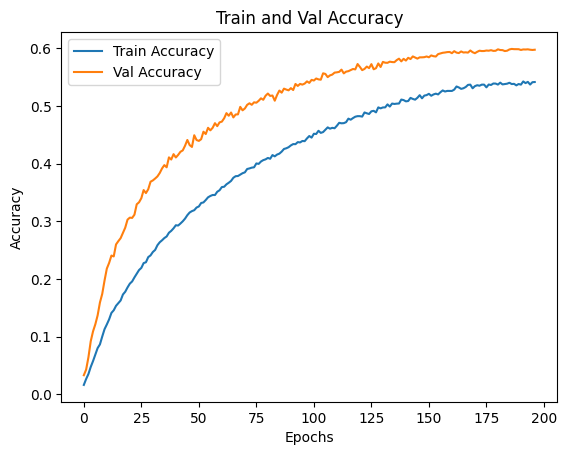

In [21]:
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Val Accuracy')
plt.ylabel("Accuracy")
plt.xlabel("Epochs")
plt.legend()
plt.title("Train and Val Accuracy")
plt.show()

## 7. Attention Rollout (Abnar & Zuidema, 2020)

Attention Rollout is a technique to visualize how information flows from the input tokens to the embeddings in deeper layers of a Transformer. It accounts for the fact that attention in higher layers is performed on representations that have already integrated information from previous layers.

The process follows these steps:
1. **Average Heads**: For each layer, average the attention weights across all attention heads.
2. **Account for Residuals**: To model the residual (skip) connections, add an identity matrix $I$ to the attention matrix $A$: $A_{adj} = 0.5A + 0.5I$.
3. **Normalization**: Re-normalize the rows of $A_{adj}$ to ensure they sum to 1.
4. **Recursive Multiplication**: Compute the rollout at layer $L$ by multiplying the adjusted attention matrices from the input layer to the target layer:
   $Rollout(L) = A_{adj}(L) \times A_{adj}(L-1) \times \dots \times A_{adj}(1)$

The resulting matrix provides a map of the relative contribution of each input patch to the tokens at layer $L$.

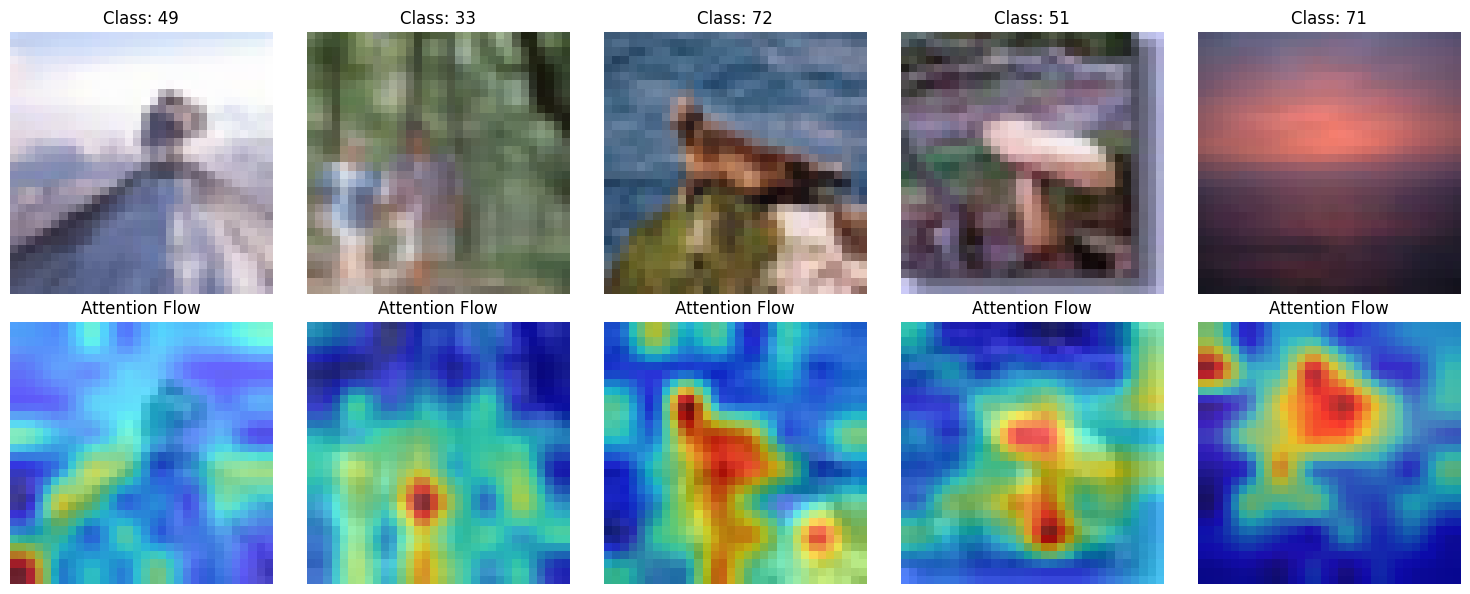

In [24]:
# --- Attention Rollout (Abnar & Zuidema, 2020) ---
import numpy as np

attention_maps = []

def hook_fn(module, input, output):
    attn_weights = output[1] if isinstance(output, tuple) and len(output) > 1 else None
    if attn_weights is not None:
        attention_maps.append(attn_weights.detach().cpu())

def visualize_attention_rollout(model, loader, img_size, num_images=5):
    global attention_maps
    model.eval()
    vit_model = model.module if hasattr(model, 'module') else model
    model_device = next(vit_model.parameters()).device

    handles = []
    for layer in vit_model.encoder:
        handles.append(layer.attn.register_forward_hook(hook_fn))

    try:
        images, labels = next(iter(loader))
    except StopIteration:
        for handle in handles:
            handle.remove()
        return

    images = images[:num_images].to(model_device)
    labels = labels[:num_images]
    actual_num_images = images.size(0)

    attention_maps = []

    try:
        with torch.no_grad():
            _ = vit_model(images)  # wichtig: kein DataParallel-Split

        if len(attention_maps) == 0:
            raise RuntimeError('No attention weights captured. Check MultiheadAttention need_weights=True.')

        rollout_maps = []

        for i in range(actual_num_images):
            first = attention_maps[0]
            if first.dim() == 4:  # [B, H, T, T]
                seq_len = first.shape[-1]
            else:  # [B, T, T]
                seq_len = first.shape[-1]

            result = torch.eye(seq_len, dtype=torch.float32)

            for layer_attn in attention_maps:
                attn = layer_attn
                if attn.dim() == 4:  # [B, H, T, T] -> [B, T, T]
                    attn = attn.mean(dim=1)

                if i >= attn.size(0):
                    raise RuntimeError('Attention batch mismatch during rollout computation.')

                attn_i = attn[i].float()
                identity = torch.eye(seq_len, dtype=attn_i.dtype)
                a_hat = 0.5 * attn_i + 0.5 * identity
                a_hat = a_hat / a_hat.sum(dim=-1, keepdim=True).clamp_min(1e-8)
                result = torch.matmul(a_hat, result)

            mask = result[0, 1:]
            width = int(np.sqrt(mask.numel()))
            mask = mask.reshape(width, width).unsqueeze(0).unsqueeze(0)
            mask = F.interpolate(mask, size=(img_size, img_size), mode='bilinear', align_corners=False)
            mask = mask.squeeze().numpy()

            denom = (mask.max() - mask.min())
            if denom > 1e-8:
                mask = (mask - mask.min()) / denom
            else:
                mask = np.zeros_like(mask)

            rollout_maps.append(mask)

        fig, axes = plt.subplots(2, actual_num_images, figsize=(3 * actual_num_images, 6))
        if actual_num_images == 1:
            axes = np.array(axes).reshape(2, 1)

        for i in range(actual_num_images):
            img = images[i].detach().cpu().permute(1, 2, 0).numpy()
            mean = np.array(stats[0])
            std = np.array(stats[1])
            img = np.clip(std * img + mean, 0, 1)

            axes[0, i].imshow(img)
            axes[0, i].set_title(f'Class: {labels[i].item()}')
            axes[0, i].axis('off')

            axes[1, i].imshow(img)
            axes[1, i].imshow(rollout_maps[i], alpha=0.6, cmap='jet')
            axes[1, i].set_title('Attention Flow')
            axes[1, i].axis('off')

        plt.tight_layout()
        plt.show()
    finally:
        for handle in handles:
            handle.remove()

visualize_attention_rollout(model, test_loader, IMG_SIZE)